In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load(r"/home/anonymous/code/AI/VolumeNeRF/crop_image/LIDC-IDRI-0002.npy")

for i in range(data.shape[0]): 
    plt.imshow(data[i], cmap='gray')
    plt.title(f'Slice {i}')
    plt.axis('off')
    plt.show()


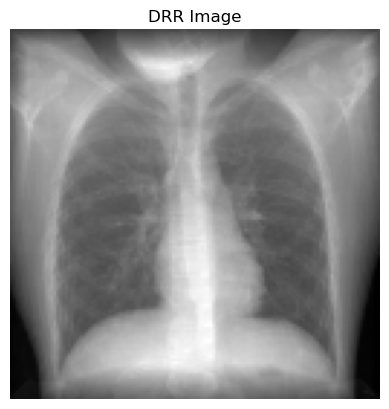

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Đường dẫn tới file DRR
drr_file = '/home/anonymous/code/AI/VolumeNeRF/drr_Xray/LIDC-IDRI-0009.npy'

# Load file .npy
drr_image = np.load(drr_file)
# print(drr_image.shape)  # Kiểm tra kích thước của ảnh DRR
# # Loại bỏ chiều thừa (từ (1, 128, 128) thành (128, 128))
drr_image = drr_image[0]  # Lấy phần tử đầu tiên của batch
# Hoặc dùng: drr_image = np.squeeze(drr_image)

# Hiển thị ảnh
plt.imshow(drr_image, cmap='gray')
plt.axis('off')
plt.title('DRR Image')
plt.show()

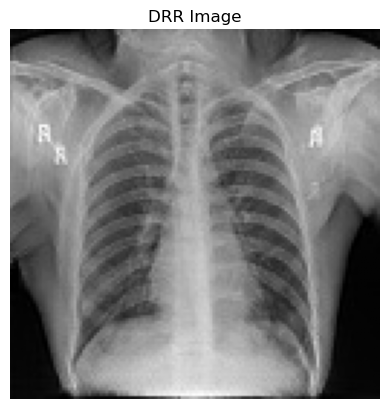

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Đường dẫn tới file DRR
drr_file = '/home/anonymous/code/AI/VolumeNeRF/synthentic_Xray/LIDC-IDRI-0009.npy'

# Load file .npy
drr_image = np.load(drr_file)

# Loại bỏ chiều thừa (từ (1, 128, 128) thành (128, 128))
drr_image = drr_image[0]  # Lấy phần tử đầu tiên của batch
# Hoặc dùng: drr_image = np.squeeze(drr_image)

# Hiển thị ảnh
plt.imshow(drr_image, cmap='gray')
plt.axis('off')
plt.title('DRR Image')
plt.show()

In [6]:
print(drr_image.shape)
print(drr_image.size)

(128, 128)
16384


In [13]:
import cv2
import os

def convert_image(img):
    # Chuyển từ RGB (hoặc BGR từ cv2) sang grayscale
    gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Dùng BGR2GRAY vì cv2.imread đọc dạng BGR
    # Resize về (128, 128)
    resized_image = cv2.resize(gray_image, (128, 128), interpolation=cv2.INTER_AREA)
    return resized_image

def main():
    # Đường dẫn thư mục nguồn và đích
    path = "/home/anonymous/code/AI/VolumeNeRF/images_fakeB"
    folder_img = "./images2D"
    os.makedirs(folder_img, exist_ok=True)

    # Duyệt qua các file trong thư mục nguồn
    for i in os.listdir(path):
        # Đường dẫn đầy đủ tới file ảnh
        img_path = os.path.join(path, i)
        # Đọc ảnh
        img = cv2.imread(img_path)
        
        # Kiểm tra xem ảnh có đọc được không
        if img is None:
            print(f"Không thể đọc file: {i}")
            continue
        
        # Chuyển đổi ảnh
        processed_img = convert_image(img)
        
        # Tạo tên file mới (lấy 14 ký tự đầu + .jpg)
        new_filename = f"{i[:14]}.jpg"
        # Đường dẫn đầy đủ để lưu file
        save_path = os.path.join(folder_img, new_filename)
        
        # Lưu ảnh đã xử lý
        cv2.imwrite(save_path, processed_img)
        print(f"Đã xử lý và lưu: {new_filename}")

if __name__ == "__main__":
    main()

Đã xử lý và lưu: LIDC-IDRI-0154.jpg
Đã xử lý và lưu: LIDC-IDRI-0607.jpg
Đã xử lý và lưu: LIDC-IDRI-0192.jpg
Đã xử lý và lưu: LIDC-IDRI-0294.jpg
Đã xử lý và lưu: LIDC-IDRI-0631.jpg
Đã xử lý và lưu: LIDC-IDRI-0251.jpg
Đã xử lý và lưu: LIDC-IDRI-0673.jpg
Đã xử lý và lưu: LIDC-IDRI-0451.jpg
Đã xử lý và lưu: LIDC-IDRI-0209.jpg
Đã xử lý và lưu: LIDC-IDRI-0203.jpg
Đã xử lý và lưu: LIDC-IDRI-0456.jpg
Đã xử lý và lưu: LIDC-IDRI-0046.jpg
Đã xử lý và lưu: LIDC-IDRI-0491.jpg
Đã xử lý và lưu: LIDC-IDRI-0358.jpg
Đã xử lý và lưu: LIDC-IDRI-0615.jpg
Đã xử lý và lưu: LIDC-IDRI-0242.jpg
Đã xử lý và lưu: LIDC-IDRI-0522.jpg
Đã xử lý và lưu: LIDC-IDRI-0354.jpg
Đã xử lý và lưu: LIDC-IDRI-0665.jpg
Đã xử lý và lưu: LIDC-IDRI-0252.jpg
Đã xử lý và lưu: LIDC-IDRI-0158.jpg
Đã xử lý và lưu: LIDC-IDRI-0632.jpg
Đã xử lý và lưu: LIDC-IDRI-0011.jpg
Đã xử lý và lưu: LIDC-IDRI-0030.jpg
Đã xử lý và lưu: LIDC-IDRI-0047.jpg
Đã xử lý và lưu: LIDC-IDRI-0101.jpg
Đã xử lý và lưu: LIDC-IDRI-0113.jpg
Đã xử lý và lưu: LIDC-IDRI-0

Mean shape: (128, 128)
Std shape: (128, 128)


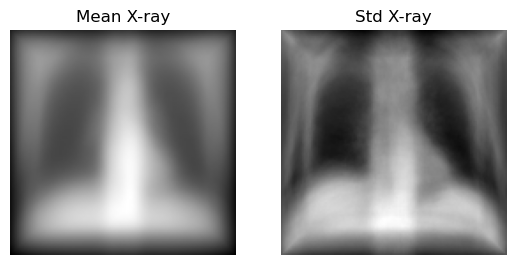

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load file
mean_xray = np.load('./DRR_Parameters/mean_xray.npy')
std_xray = np.load('./DRR_Parameters/std_xray.npy')

# Loại bỏ chiều thừa
mean_xray = np.squeeze(mean_xray)  # Từ (1, 128, 128) thành (128, 128)
std_xray = np.squeeze(std_xray)    # Từ (1, 128, 128) thành (128, 128)

# Kiểm tra shape
print("Mean shape:", mean_xray.shape)  # Phải là (128, 128)
print("Std shape:", std_xray.shape)    # Phải là (128, 128)

# Visualize
plt.subplot(121)
plt.imshow(mean_xray, cmap='gray')
plt.title('Mean X-ray')
plt.axis('off')  # Tắt trục cho đẹp

plt.subplot(122)
plt.imshow(std_xray, cmap='gray')
plt.title('Std X-ray')
plt.axis('off')

plt.show()